In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('gym_members_exercise_tracking.csv')

In [3]:
print(df.head())


   Age  Gender  Weight (kg)  Height (m)  Max_BPM  Avg_BPM  Resting_BPM  \
0   56    Male         88.3        1.71      180      157           60   
1   46  Female         74.9        1.53      179      151           66   
2   32  Female         68.1        1.66      167      122           54   
3   25    Male         53.2        1.70      190      164           56   
4   38    Male         46.1        1.79      188      158           68   

   Session_Duration (hours)  Calories_Burned Workout_Type  Fat_Percentage  \
0                      1.69           1313.0         Yoga            12.6   
1                      1.30            883.0         HIIT            33.9   
2                      1.11            677.0       Cardio            33.4   
3                      0.59            532.0     Strength            28.8   
4                      0.64            556.0     Strength            29.2   

   Water_Intake (liters)  Workout_Frequency (days/week)  Experience_Level  \
0              

In [4]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int

In [5]:
print(df.describe())


              Age  Weight (kg)  Height (m)     Max_BPM     Avg_BPM  \
count  973.000000   973.000000   973.00000  973.000000  973.000000   
mean    38.683453    73.854676     1.72258  179.883864  143.766701   
std     12.180928    21.207500     0.12772   11.525686   14.345101   
min     18.000000    40.000000     1.50000  160.000000  120.000000   
25%     28.000000    58.100000     1.62000  170.000000  131.000000   
50%     40.000000    70.000000     1.71000  180.000000  143.000000   
75%     49.000000    86.000000     1.80000  190.000000  156.000000   
max     59.000000   129.900000     2.00000  199.000000  169.000000   

       Resting_BPM  Session_Duration (hours)  Calories_Burned  Fat_Percentage  \
count   973.000000                973.000000       973.000000      973.000000   
mean     62.223022                  1.256423       905.422405       24.976773   
std       7.327060                  0.343033       272.641516        6.259419   
min      50.000000                  0.500000 

In [6]:
print(df.isnull().sum())

Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Calories_Burned                  0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64


In [7]:
print('Duplicate Rows:', df.duplicated().sum())


Duplicate Rows: 0


In [10]:
df.columns = [col.lower().replace(' ', '_').replace('(', '').replace(')', '') for col in df.columns]
print(df.columns)

Index(['age', 'gender', 'weight_kg', 'height_m', 'max_bpm', 'avg_bpm',
       'resting_bpm', 'session_duration_hours', 'calories_burned',
       'workout_type', 'fat_percentage', 'water_intake_liters',
       'workout_frequency_days/week', 'experience_level', 'bmi'],
      dtype='object')


In [19]:
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    
    print(f"\nColumn: {col}")
    print("Missing Before:", df[col].isnull().sum())
    
    df[col] = df[col].fillna(df[col].median())
    
    print("Missing After:", df[col].isnull().sum())


Column: age
Missing Before: 0
Missing After: 0

Column: weight_kg
Missing Before: 0
Missing After: 0

Column: height_m
Missing Before: 0
Missing After: 0

Column: max_bpm
Missing Before: 0
Missing After: 0

Column: avg_bpm
Missing Before: 0
Missing After: 0

Column: resting_bpm
Missing Before: 0
Missing After: 0

Column: session_duration_hours
Missing Before: 0
Missing After: 0

Column: calories_burned
Missing Before: 0
Missing After: 0

Column: fat_percentage
Missing Before: 0
Missing After: 0

Column: water_intake_liters
Missing Before: 0
Missing After: 0

Column: workout_frequency_days/week
Missing Before: 0
Missing After: 0

Column: experience_level
Missing Before: 0
Missing After: 0

Column: bmi
Missing Before: 0
Missing After: 0


In [20]:
for col in df.select_dtypes(include=['object']).columns:
    
    print(f"\nColumn: {col}")
    print("Missing Before:", df[col].isnull().sum())
    
    df[col] = df[col].fillna(df[col].mode()[0])
    
    print("Missing After:", df[col].isnull().sum())


Column: gender
Missing Before: 0
Missing After: 0

Column: workout_type
Missing Before: 0
Missing After: 0

Column: age_group
Missing Before: 0
Missing After: 0


In [16]:
def age_group(age):
    if age < 25:
        return '18-24'
    elif age < 35:
        return '25-34'
    elif age < 45:
        return '35-44'
    else:
        return '45+'


df['age_group'] = df['age'].apply(age_group)

In [18]:
print(df['age_group'])

0        45+
1        45+
2      25-34
3      25-34
4      35-44
       ...  
968    18-24
969    25-34
970      45+
971    25-34
972      45+
Name: age_group, Length: 973, dtype: object


In [21]:
df['workout_intensity'] = round(df['avg_bpm'] / df['max_bpm'], 2)

In [22]:
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'


df['bmi_category'] = df['bmi'].apply(bmi_category)


In [23]:
print(df['bmi_category'])

0            Obese
1            Obese
2           Normal
3      Underweight
4      Underweight
          ...     
968     Overweight
969     Overweight
970         Normal
971          Obese
972          Obese
Name: bmi_category, Length: 973, dtype: object


In [24]:
df.to_csv('cleaned_athlete_data.csv', index=False)
print(df.head())

   age  gender  weight_kg  height_m  max_bpm  avg_bpm  resting_bpm  \
0   56    Male       88.3      1.71      180      157           60   
1   46  Female       74.9      1.53      179      151           66   
2   32  Female       68.1      1.66      167      122           54   
3   25    Male       53.2      1.70      190      164           56   
4   38    Male       46.1      1.79      188      158           68   

   session_duration_hours  calories_burned workout_type  fat_percentage  \
0                    1.69           1313.0         Yoga            12.6   
1                    1.30            883.0         HIIT            33.9   
2                    1.11            677.0       Cardio            33.4   
3                    0.59            532.0     Strength            28.8   
4                    0.64            556.0     Strength            29.2   

   water_intake_liters  workout_frequency_days/week  experience_level    bmi  \
0                  3.5                          

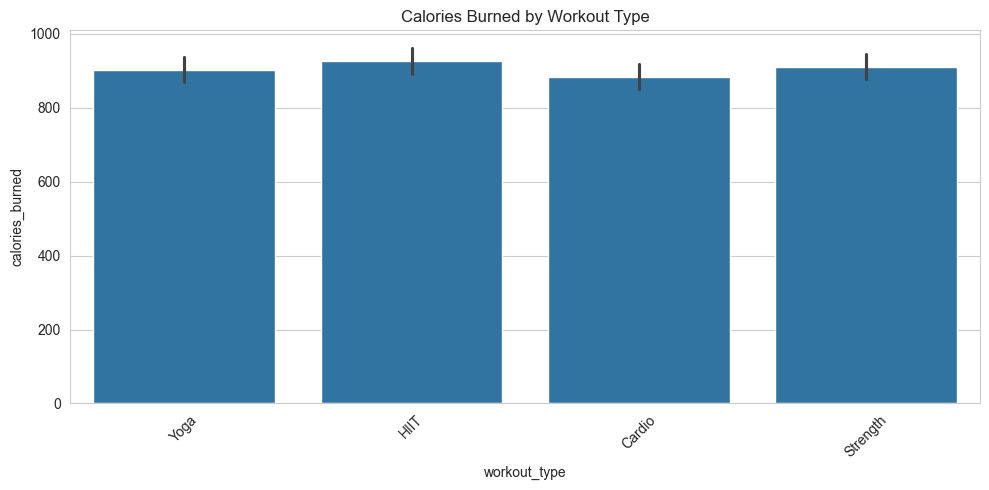

In [25]:
sns.set_style('whitegrid')

# Calories Burned by Workout Type

plt.figure(figsize=(10,5))
sns.barplot(x='workout_type', y='calories_burned', data=df)
plt.title('Calories Burned by Workout Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('calories_by_workout.png')
plt.show()

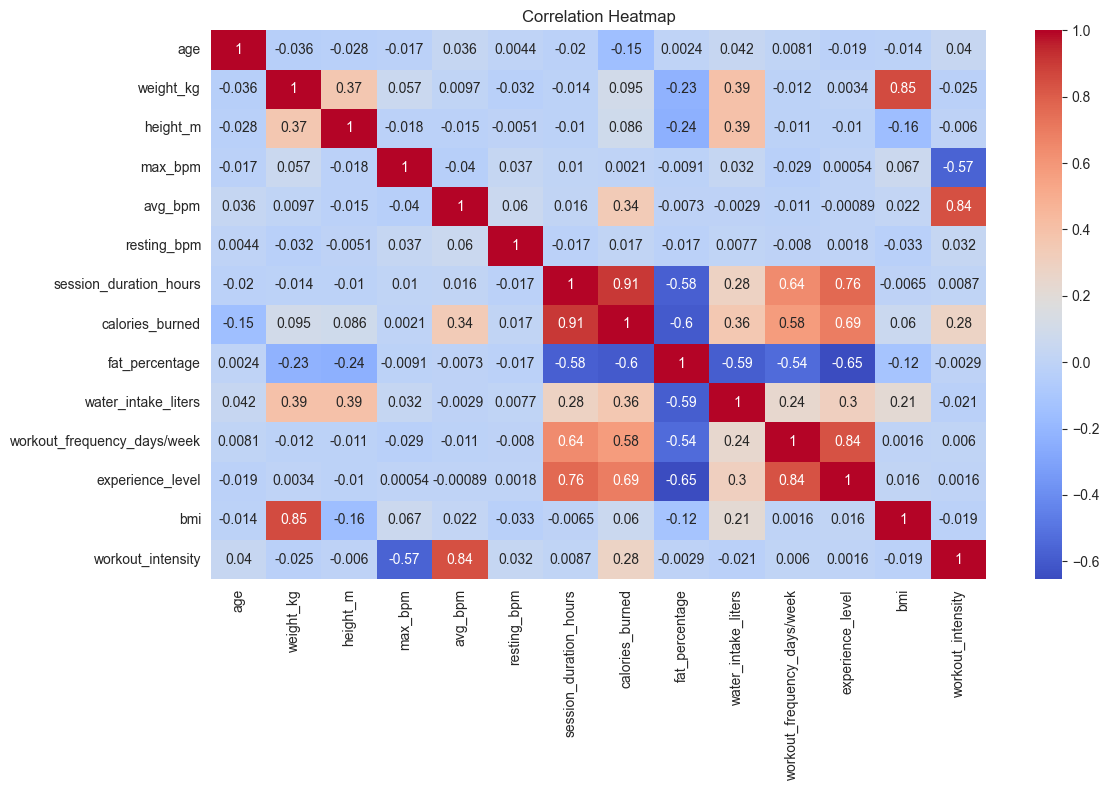

In [26]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['float64', 'int64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()


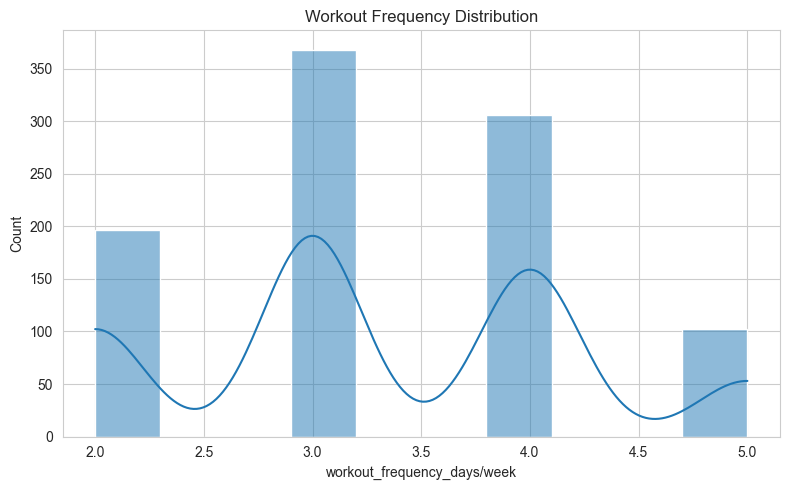

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(df['workout_frequency_days/week'], bins=10, kde=True)
plt.title('Workout Frequency Distribution')
plt.tight_layout()
plt.savefig('workout_frequency.png')
plt.show()


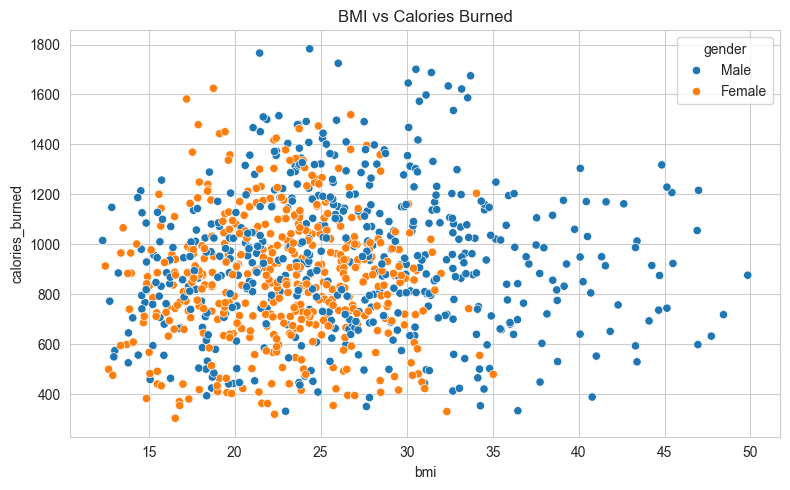

In [28]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='bmi', y='calories_burned', hue='gender', data=df)
plt.title('BMI vs Calories Burned')
plt.tight_layout()
plt.savefig('bmi_vs_calories.png')
plt.show()


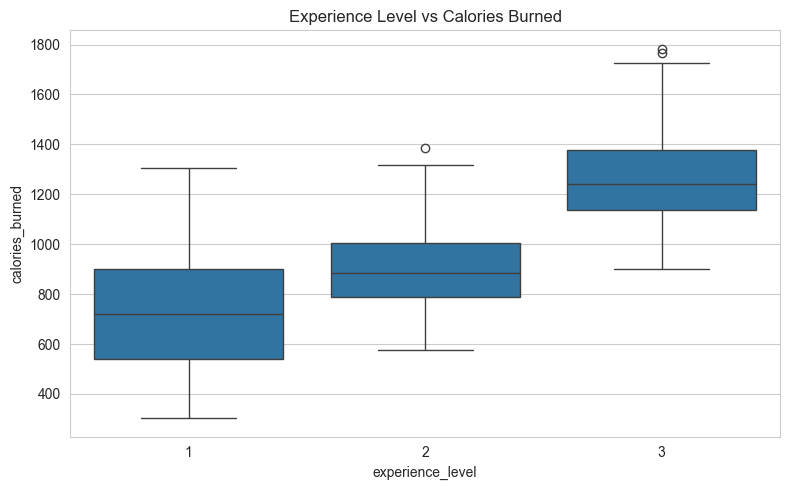

In [29]:
plt.figure(figsize=(8,5))
sns.boxplot(x='experience_level', y='calories_burned', data=df)
plt.title('Experience Level vs Calories Burned')
plt.tight_layout()
plt.savefig('experience_level.png')
plt.show()


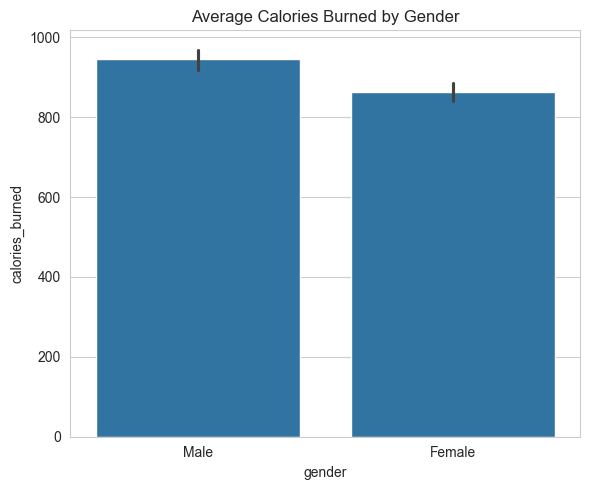

In [30]:
plt.figure(figsize=(6,5))
sns.barplot(x='gender', y='calories_burned', data=df)
plt.title('Average Calories Burned by Gender')
plt.tight_layout()
plt.savefig('gender_calories.png')
plt.show()



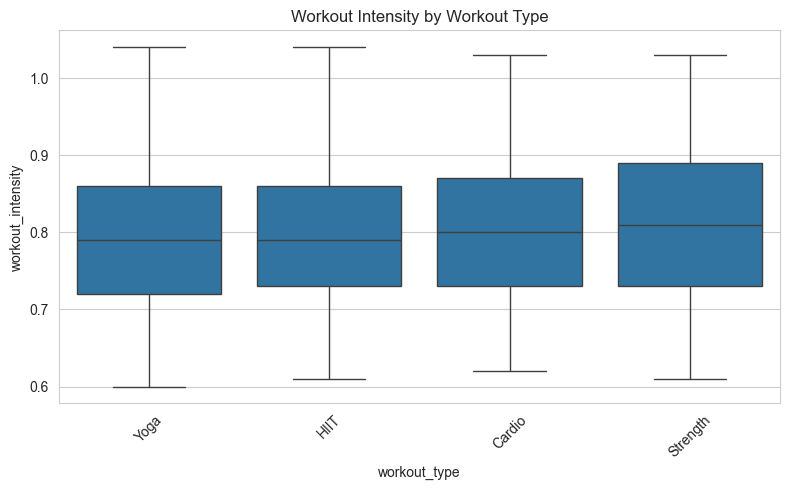

In [31]:
# Workout Intensity Analysis

plt.figure(figsize=(8,5))
sns.boxplot(x='workout_type', y='workout_intensity', data=df)
plt.title('Workout Intensity by Workout Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('workout_intensity.png')
plt.show()

In [34]:
print("===== KPI REPORT =====\n")

print('Average Calories Burned:', round(df['calories_burned'].mean(), 2))
print('Average Session Duration:', round(df['session_duration_hours'].mean(), 2))
print('Average BMI:', round(df['bmi'].mean(), 2))
print('Highest Calories Burned:', round(df['calories_burned'].max(), 2))
print('Most Common Workout Type:', df['workout_type'].mode()[0])

# Top Performing Workout Type

top_workout = df.groupby('workout_type')['calories_burned'].mean().sort_values(ascending=False)

print("\nTop Workout Types by Calories Burned:\n")
print(top_workout)

# -----------------------------
# Business Insights
# -----------------------------

print("\n===== BUSINESS INSIGHTS =====\n")

print('- HIIT and Cardio workouts showed higher average calorie burn compared to Yoga.')
print('- Higher workout frequency was associated with increased calorie expenditure.')
print('- Experienced athletes demonstrated better workout efficiency and lower resting BPM.')
print('- Water intake showed a positive relationship with workout duration and performance.')
print('- Athletes with moderate BMI ranges displayed more consistent workout intensity.')

===== KPI REPORT =====

Average Calories Burned: 905.42
Average Session Duration: 1.26
Average BMI: 24.91
Highest Calories Burned: 1783.0
Most Common Workout Type: Strength

Top Workout Types by Calories Burned:

workout_type
HIIT        925.805430
Strength    910.697674
Yoga        903.188285
Cardio      884.513725
Name: calories_burned, dtype: float64

===== BUSINESS INSIGHTS =====

- HIIT and Cardio workouts showed higher average calorie burn compared to Yoga.
- Higher workout frequency was associated with increased calorie expenditure.
- Experienced athletes demonstrated better workout efficiency and lower resting BPM.
- Water intake showed a positive relationship with workout duration and performance.
- Athletes with moderate BMI ranges displayed more consistent workout intensity.
